# Part 7 — latent geometry: the `balanced_bce` family

Continues the AE-only → BCE → contrastive chain `part_3` started: BCE is now the
"previous" stage, compared pairwise against all five other `balanced_bce`-family
objectives (`grid_0001`/`+contractive`, `grid_0002`/`+peak_random`,
`grid_0003`/`+peak_label_invariant`, `grid_0004`/`+contractive+peak_label_invariant`,
`grid_0005`/`grid_0004+negw_multilabel_jaccard`), using the metric battery from
`../report/geometria_latentu.md` Część II-III (metric, what LayerNorm constrains) and
Część V's checklists (canonicalization/pipeline checks, structure-vs-baseline,
dimension usage, cloud asymmetry). All $\binom{6}{2}=15$ pairs among the six
objectives are compared directly, not just each vs. `bce` — the prior 4-objective pass
found `+contractive` is the only one of the first three extra terms whose geometric
effect survives the seed-noise null check (against `bce` *and* against both
contrastive variants), so whether that pattern persists once `+contractive` is
combined with `+peak_label_invariant` (`grid_0004`) and then with
`+negw_multilabel_jaccard` (`grid_0005`) is the key new question here.

**Unlike `part_3`**, no pixel-intersection trick is needed: all six objectives share
one dataset/split (verified in `part_5`), so the full train and test splits are usable
directly, not the 42/2662-pixel overlap `part_3` was limited to. Large-`N` metrics
(`TwoNN`, Procrustes, CKA, `k`NN-overlap, trustworthiness — all `O(N^2)`) use a fixed
random subsample of `train`; `test` (4023 pixels) is used in full.

**Deferred, not implemented in this pass**: alignment/uniformity and the
"contrastive-selectivity" angular curve (`geometria_latentu.md`'s "analiza
specjalistyczna" checklist, contrastive-specific rows) both need the *same*
peak-permutation augmentation `InfoNCELoss` uses internally (stateful,
precomputed-catalog machinery — `training.criterions.autoencoder.contrastive.
infoNCE_loss.MSIInfoNCELoss`) to build the "positive pair" / structured perturbation.
Reusing it correctly needs its own investigation; the general (random-direction)
encoder-sensitivity curve is computed here as it was in `part_3`/`part_4`, which does
not need it.


In [1]:
import itertools
import os
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.visualization import resolve_theme


2026-08-28 14:44:43,393 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.
2026-08-28 14:44:43,402 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.
2026-08-28 14:44:44,267 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.
2026-08-28 14:44:44,269 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.
2026-08-28 14:44:44,273 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.
2026-08-28 14

## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
CAMPAIGN_ID = "kidney-architecture-predictive__cfg_529dc0e4494b"

MODEL_NAMES = {
    "bce": f"{CAMPAIGN_ID}__grid_0000__rep_00",
    "contractive": f"{CAMPAIGN_ID}__grid_0001__rep_00",
    "peak_random": f"{CAMPAIGN_ID}__grid_0002__rep_00",
    "peak_label_invariant": f"{CAMPAIGN_ID}__grid_0003__rep_00",
    "grid4": f"{CAMPAIGN_ID}__grid_0004__rep_00",
    "grid5": f"{CAMPAIGN_ID}__grid_0005__rep_00",
}
MODEL_LABELS = {
    "bce": "bce",
    "contractive": "+contractive",
    "peak_random": "+peak_random",
    "peak_label_invariant": "+peak_label_invariant",
    "grid4": "+contractive+peak_label_invariant",
    "grid5": "+contractive+peak_label_invariant+jaccard",
}
PAIRS = list(itertools.combinations(MODEL_NAMES, 2))  # all 15 pairs among the 6 objectives

BATCH_SIZE = 256
RANDOM_SEED = 42
TRAIN_SAMPLE_SIZE = 3000
PAIR_COUNT = 20000
KNN_K = 10

theme = resolve_theme(None)
theme.apply()
model_colors = {label: theme.color_for_model(label, index) for index, label in enumerate(MODEL_LABELS.values())}
theme = replace(theme, model_overrides=model_colors)
theme.apply()


## Load all six models and a shared pixel sample


In [3]:
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())

wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

# All six objectives share one image/binner/annotation-store/dataset context —
# only the model weights differ (verified in part_5). `load_configuration`
# unconditionally re-resolves the raw imzML reader (measured ~38-40s) on every call;
# `models_manager.load_model` swaps only the model architecture/weights and leaves
# context untouched (measured ~0.04s) — pay the full cost once, then use the
# lightweight swap for the remaining five objectives.
models, gammas, betas, devices = {}, {}, {}, {}
for index, (key, model_name) in enumerate(MODEL_NAMES.items()):
    if index == 0:
        wrapper.load_configuration(model_name=model_name)
        models[key] = wrapper.active_model
    else:
        models[key] = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
    models[key].eval()
    devices[key] = next(models[key].parameters()).device
    gammas[key], betas[key] = geometry.encoder_layer_norm_parameters(models[key])

reference_partitions = wrapper.active_dataset.create_partitions()

rng = np.random.default_rng(RANDOM_SEED)
train_ids_all = np.asarray(reference_partitions.manifest.assignments["train"])
train_ids = rng.choice(train_ids_all, size=min(TRAIN_SAMPLE_SIZE, len(train_ids_all)), replace=False).tolist()
test_ids = list(reference_partitions.manifest.assignments["test"])
ids_by_split = {"train": train_ids, "test": test_ids}
print(f"train sample: {len(train_ids)} pixel(s); test: {len(test_ids)} pixel(s)")


2026-08-28 14:44:44,788 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32
2026-08-28 14:44:44,789 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.
2026-08-28 14:44:44,790 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.
2026-08-28 14:44:44,791 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.
2026-08-28 14:44:44,793 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.
2026-08-28 14:44:44,795 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discov

## Encode, canonicalize, and verify

### Methodology
#### Theoretical
- Before any geometry comparison across the six objectives, the canonicalization
  pipeline itself must be verified correct for every model, and a known confound
  (`+contractive`'s latent collapse, first found in `part_4`) must be re-confirmed
  present here too, so later sections' "no effect" reads are not mistaken for a
  broken pipeline.

#### Implementation
- Every model has its own saved dataset object (via its own `load_configuration`
  call) but all six enumerate the same underlying spectra in the same split order
  (verified in `part_5`), so `ids_by_split` indexes correctly into any of them.
  Verification here covers three of `geometria_latentu.md`'s Część V "przestrzeń
  ukryta" checklist items: (1) `verify_canonicalization` — both LayerNorm
  constraints hold on $u$; (2) `null_direction_check` — the discarded PCA direction
  aligns with $1/\gamma$, confirming the canonicalization pipeline itself is
  correct (`part_4`'s Check 0 found this is a weak check in practice, since
  $1/\gamma$'s own alignment with the constant direction can be high regardless —
  kept for consistency, not read as a strong signal); (3) `cloud_asymmetry` —
  `part_4` found this separates `+contractive` (collapsed, ≈0.96) from `bce`
  (≈0.42) sharply; checked here for all six objectives together.

### Notes


In [4]:
def encode_ids(model, device, split_name: str, spectrum_ids: list[int]) -> np.ndarray:
    dataset = getattr(reference_partitions, split_name)
    index_by_id = {sid: index for index, sid in enumerate(reference_partitions.manifest.assignments[split_name])}
    ordered_indices = [index_by_id[sid] for sid in spectrum_ids]
    spectra = torch.stack([dataset[index][1] for index in ordered_indices]).float()
    latents = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            batch = spectra[start : start + BATCH_SIZE].to(device)
            latents.append(model(batch)["latent_space"].cpu().numpy())
    return np.concatenate(latents, axis=0)


u_by_split_model = {}
verification_rows = []
for split_name, ids in ids_by_split.items():
    for key in MODEL_NAMES:
        z = encode_ids(models[key], devices[key], split_name, ids)
        u = geometry.canonicalize(z, gammas[key], betas[key])
        u_by_split_model[(split_name, key)] = u
        verification_rows.append({
            "split": split_name,
            "model": MODEL_LABELS[key],
            **geometry.verify_canonicalization(u),
            **geometry.null_direction_check(u, gammas[key]),
            "cloud_asymmetry": geometry.cloud_asymmetry(u),
        })
    print(f"{split_name}: encoded through all 6 models")

pd.DataFrame(verification_rows)


/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/binners/base_binner.py:46: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  intensity_tensor = torch.as_tensor(intensities, dtype=self.dtype)


train: encoded through all 6 models
test: encoded through all 6 models


,split,model,max_abs_row_sum,expected_norm,mean_row_norm,max_abs_norm_deviation,smallest_eigenvalue,cosine_with_constant_direction,cosine_with_inverse_gamma,cloud_asymmetry
0,train,bce,8.652968e-07,3.162278,3.162275,0.000007,5.105946e-15,1.0,0.999031,0.505557
1,train,+contractive,8.323029e-07,3.162278,3.162277,0.000002,4.980950e-15,1.0,0.999515,0.972636
2,train,+peak_random,7.717857e-07,3.162278,3.162275,0.000007,5.054091e-15,1.0,0.999460,0.554372
3,train,+peak_label_invariant,8.488167e-07,3.162278,3.162275,0.000008,5.325625e-15,1.0,0.999441,0.522582
4,train,+contractive+peak_label_invariant,7.972232e-07,3.162278,3.162277,0.000002,4.814209e-15,1.0,0.998610,0.970207
5,train,+contractive+peak_label_invariant+jaccard,7.891142e-07,3.162278,3.162277,0.000002,4.775968e-15,1.0,0.998770,0.973229
6,test,bce,8.782833e-07,3.162278,3.162274,0.000006,5.257715e-15,1.0,0.999031,0.349329
7,test,+contractive,8.593526e-07,3.162278,3.162277,0.000001,5.482919e-15,1.0,0.999515,0.956768
8,test,+peak_random,9.153493e-07,3.162278,3.162275,0.000005,4.583826e-15,1.0,0.999460,0.496158
9,test,+peak_label_invariant,8.995417e-07,3.162278,3.162275,0.000005,4.660535e-15,1.0,0.999441,0.439485


## Is there any structure at all

### Methodology
#### Theoretical
- We test whether the observed random-pair $\cos\theta$ distribution differs from
  what i.i.d. uniform points on the sphere would produce (`geometria_latentu.md`
  §3.1). If the observed spread is statistically indistinguishable from the
  closed-form uniform-sphere null (mean ≈ 0, sd ≈ the analytic baseline), the latent
  carries no directional structure at all. A narrower spread indicates clustering; a
  skewed or multi-modal shape (invisible in the summary mean/sd, visible only in the
  raw distribution) indicates polarized or multi-cluster structure rather than
  uniform noise.

#### Implementation
- `sphere_geometry.structure_test(u, structure_rng, pair_count, return_samples=True)`
  draws `pair_count` random index pairs from the canonicalized codes `u` (discarding
  self-pairs) and computes `cos_theta = (u_i · u_j) / D` per pair — division by `D`,
  not by the product of norms, because every canonicalized row has norm $\sqrt{D}$
  exactly (`canonicalize`'s own invariant). `return_samples=True` additionally
  returns the raw per-pair array (`cos_theta_samples`), otherwise only the summary
  (mean, sd, closed-form uniform-sphere sd baseline $\sqrt{1/(D-1)}$) is returned.
  The violin plot below renders these raw values directly
  (`matplotlib.axes.Axes.violinplot`), one violin per (split, objective).

### Notes
- See the violin plot below for what the summary table's mean/sd cannot show on
  their own.


In [5]:
structure_rng = np.random.default_rng(RANDOM_SEED + 1)
structure_rows = []
cos_theta_samples_by_group = {}
for split_name in ids_by_split:
    for key in MODEL_NAMES:
        u = u_by_split_model[(split_name, key)]
        pairs = min(PAIR_COUNT, u.shape[0] * (u.shape[0] - 1))
        result = geometry.structure_test(u, structure_rng, pair_count=pairs, return_samples=True)
        cos_theta_samples_by_group[(split_name, MODEL_LABELS[key])] = result.pop("cos_theta_samples")
        structure_rows.append({"split": split_name, "model": MODEL_LABELS[key], **result})

pd.DataFrame(structure_rows)

,split,model,observed_mean_cos_theta,observed_sd_cos_theta,uniform_baseline_sd_cos_theta,effective_dimension
0,train,bce,0.502453,0.340935,0.333333,8.0
1,train,+contractive,0.972521,0.022644,0.333333,8.0
2,train,+peak_random,0.553545,0.302538,0.333333,8.0
3,train,+peak_label_invariant,0.524154,0.320497,0.333333,8.0
4,train,+contractive+peak_label_invariant,0.970036,0.026949,0.333333,8.0
5,train,+contractive+peak_label_invariant+jaccard,0.973397,0.023521,0.333333,8.0
6,test,bce,0.351135,0.511914,0.333333,8.0
7,test,+contractive,0.956398,0.038739,0.333333,8.0
8,test,+peak_random,0.498064,0.405689,0.333333,8.0
9,test,+peak_label_invariant,0.438667,0.448294,0.333333,8.0


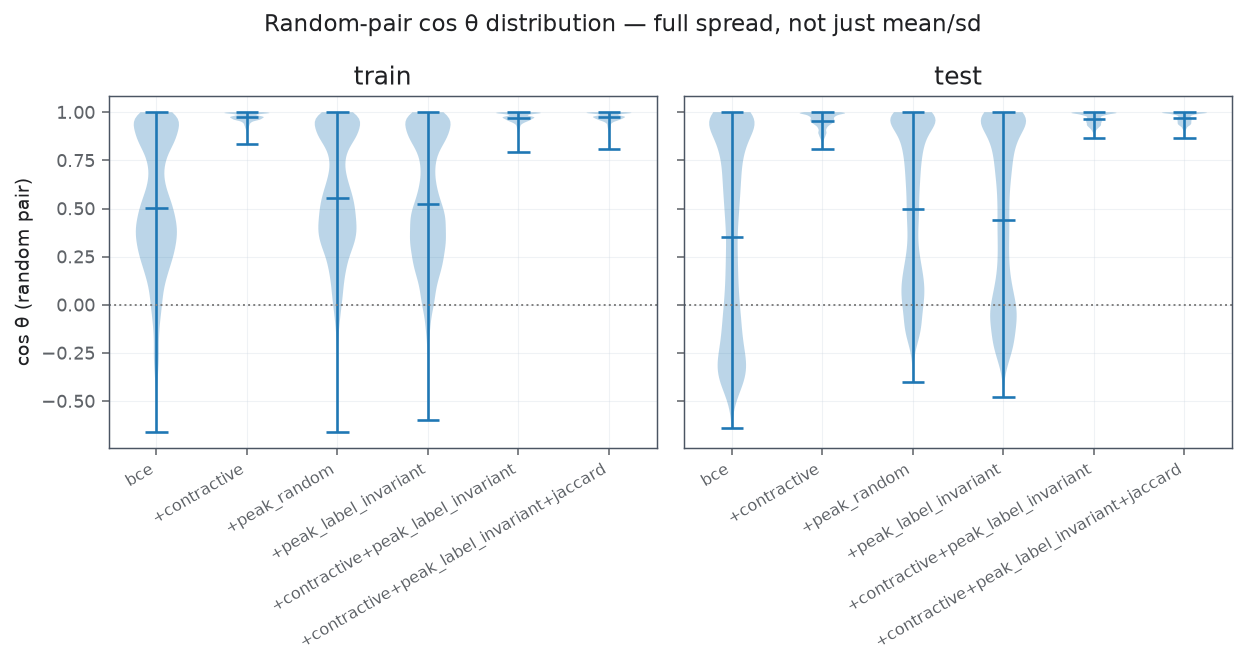

In [6]:
import matplotlib.pyplot as plt

split_names = list(ids_by_split)
model_labels = [MODEL_LABELS[key] for key in MODEL_NAMES]

figure, axes = plt.subplots(1, len(split_names), figsize=(9.0, 4.8), dpi=theme.figure_dpi, sharey=True)
if len(split_names) == 1:
    axes = [axes]
for axis, split_name in zip(axes, split_names):
    samples = [cos_theta_samples_by_group[(split_name, label)] for label in model_labels]
    axis.violinplot(samples, showmeans=True, showextrema=True)
    axis.axhline(0.0, color="grey", linestyle=":", linewidth=1)
    axis.set_xticks(range(1, len(model_labels) + 1))
    axis.set_xticklabels(model_labels, rotation=30, ha="right", fontsize=8)
    axis.set(ylabel="cos θ (random pair)" if axis is axes[0] else "", title=split_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Random-pair cos θ distribution — full spread, not just mean/sd", fontsize=12)
figure.tight_layout()

## Dimension usage

### Methodology
#### Theoretical
- Whether each objective's latent uses most of its available dimensions or
  concentrates variance onto a handful of them, across all six objectives at once —
  extends `part_3`'s AE-only-vs-BCE check to the full `balanced_bce` family.

#### Implementation
- `geometry.dimension_usage(u)` per `(split, objective)`: eigenvalue spectrum of
  $\operatorname{Cov}(u)$ (population, `ddof=0`), reduced to `effective_rank` and
  `participation_ratio`, plus the raw `trace(Cov(u))` (total variance budget).

### Notes
- `trace(Cov(u))` (test): the non-`+contractive` objectives sit at 5.0-6.5; every
  `+contractive`-containing objective collapses to 0.30-0.43 — the same
  latent-collapse signature `part_4` found for `+contractive` alone, now confirmed
  to persist when `+contractive` is combined with the other terms
  (`grid_0004`/`grid_0005` collapse *at least as much* as plain `+contractive`, not
  less).


In [7]:
dimension_rows = []
spectra_by_key = {}
for split_name in ids_by_split:
    for key in MODEL_NAMES:
        u = u_by_split_model[(split_name, key)]
        result = geometry.dimension_usage(u)
        spectra_by_key[(split_name, key)] = result["eigenvalues"]
        dimension_rows.append({
            "split": split_name, "model": MODEL_LABELS[key],
            "trace": result["trace"], "effective_rank": result["effective_rank"],
            "participation_ratio": result["participation_ratio"],
        })

pd.DataFrame(dimension_rows)


,split,model,trace,effective_rank,participation_ratio
0,train,bce,4.944411,4.501413,3.237920
1,train,+contractive,0.273635,4.333651,3.313212
2,train,+peak_random,4.456264,4.519922,3.355998
3,train,+peak_label_invariant,4.774165,4.433774,3.198284
4,train,+contractive+peak_label_invariant,0.297925,4.228839,3.182427
5,train,+contractive+peak_label_invariant+jaccard,0.267712,4.249267,3.181170
6,test,bce,6.506682,2.473709,1.750745
7,test,+contractive,0.432314,2.185889,1.584907
8,test,+peak_random,5.038403,2.523669,1.744307
9,test,+peak_label_invariant,5.605135,2.422784,1.728121


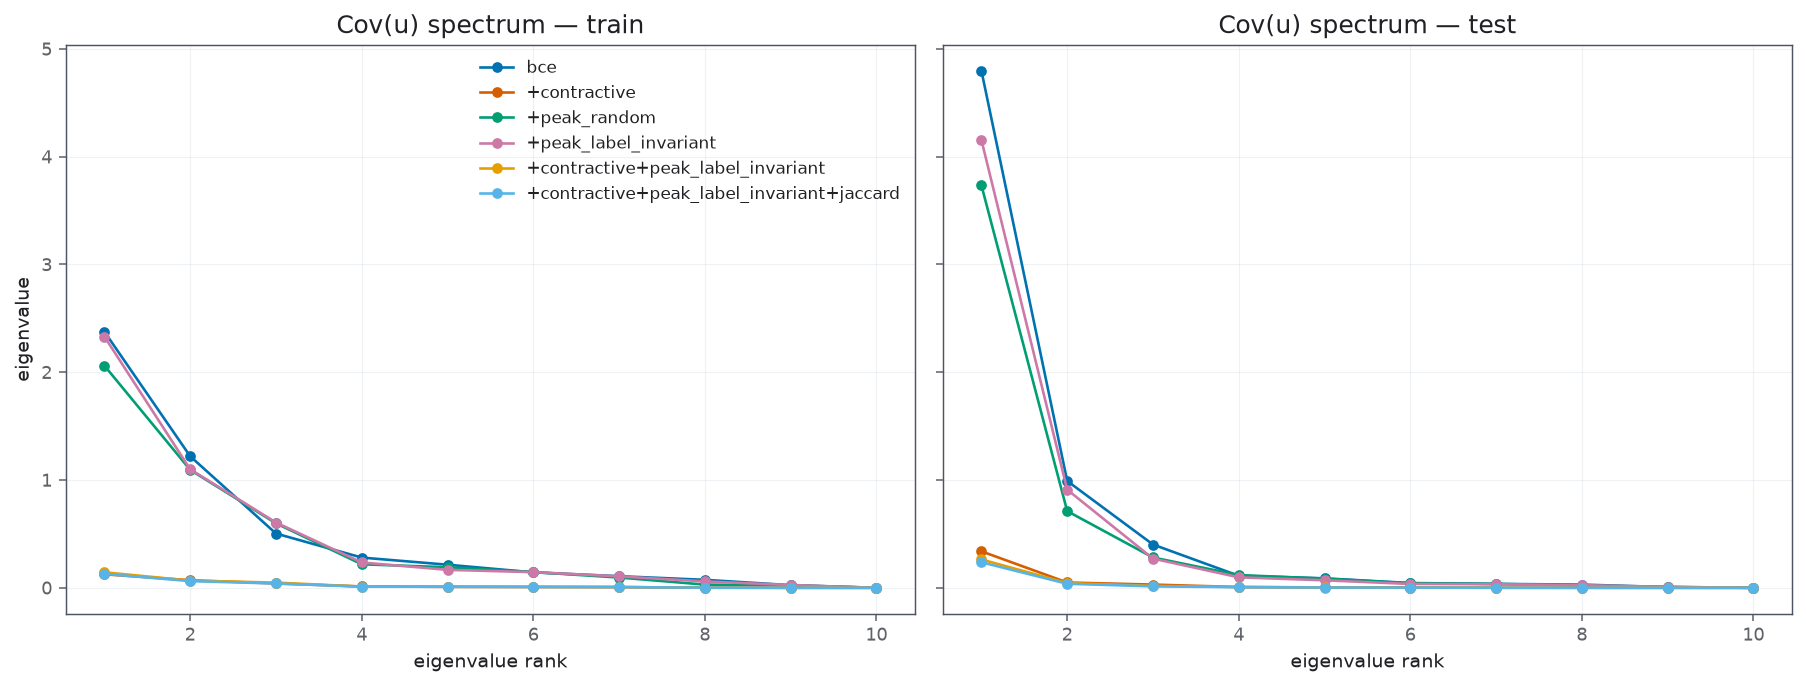

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), dpi=theme.figure_dpi, sharey=True)
for ax, split_name in zip(axes, ids_by_split):
    for index, key in enumerate(MODEL_NAMES):
        label = MODEL_LABELS[key]
        ax.plot(np.arange(1, 11), spectra_by_key[(split_name, key)], marker="o", color=theme.color_for_model(label, index), label=label)
    ax.set(xlabel="eigenvalue rank", title=f"Cov(u) spectrum — {split_name}")
    ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
axes[0].set_ylabel("eigenvalue")
axes[0].legend(frameon=theme.legend_frame)
figure.tight_layout()


## Intrinsic dimension (TwoNN)

### Methodology
#### Theoretical
- A non-linear, local complement to `dimension_usage`'s global covariance-based
  estimate — checks whether the same collapse shows up in a metric that is largely
  insensitive to isotropic rescaling.

#### Implementation
- `geometry.two_nn_intrinsic_dimension(u)` per `(split, objective)`.

### Notes
- Shows the same two-cluster split far more mildly than the other metrics: the
  non-`+contractive` objectives sit around ~5.7-5.75, `+contractive`-containing
  objectives around ~5.2-5.3 — expected, since TwoNN is largely insensitive to the
  isotropic-scale collapse `+contractive` produces (`part_4`'s original finding,
  confirmed again here).


In [9]:
two_nn_rows = []
for split_name in ids_by_split:
    for key in MODEL_NAMES:
        u = u_by_split_model[(split_name, key)]
        two_nn_rows.append({"split": split_name, "model": MODEL_LABELS[key], "n_samples": u.shape[0], "two_nn_intrinsic_dimension": geometry.two_nn_intrinsic_dimension(u)})

pd.DataFrame(two_nn_rows)


,split,model,n_samples,two_nn_intrinsic_dimension
0,train,bce,3000,5.772231
1,train,+contractive,3000,4.985820
2,train,+peak_random,3000,5.908823
3,train,+peak_label_invariant,3000,5.610926
4,train,+contractive+peak_label_invariant,3000,4.956576
5,train,+contractive+peak_label_invariant+jaccard,3000,4.980513
6,test,bce,4023,5.689160
7,test,+contractive,4023,5.223831
8,test,+peak_random,4023,5.749425
9,test,+peak_label_invariant,4023,5.734440


## Pairwise geometry — all 15 pairs among the 6 objectives

### Methodology
#### Theoretical
- Direct, paired shape/neighborhood comparison between every pair of objectives
  (`\binom{6}{2}=15` pairs), row-aligned on the same shared pixels — the raw
  material the seed-noise null check below interprets.

#### Implementation
- For each of the 15 pairs: `geometry.procrustes_distance`, `geometry.linear_cka`,
  `geometry.knn_overlap` (k=10), all on the same row-aligned pixels per split
  (`itertools.combinations(MODEL_NAMES, 2)` via `PAIRS`).

### Notes
- This table is a single (`rep_00`-only) snapshot per pair — a raw pairwise
  distance is not itself evidence of a real difference until compared against the
  seed-to-seed spread. The seed-noise section below recomputes these same pairs
  across all 5 repetitions and plots the actual distribution (violin + individual
  points) for `procrustes_distance`, `linear_cka`, and `knn_overlap` — see that
  plot rather than this table for anything more than a rough first look.


In [10]:
pairwise_rows = []
for split_name in ids_by_split:
    for left_key, right_key in PAIRS:
        u_left = u_by_split_model[(split_name, left_key)]
        u_right = u_by_split_model[(split_name, right_key)]
        knn_k = min(KNN_K, u_left.shape[0] - 1)
        trust_cont = geometry.trustworthiness_continuity(u_left, u_right, n_neighbors=knn_k)
        pairwise_rows.append({
            "split": split_name,
            "pair": f"{MODEL_LABELS[left_key]} vs {MODEL_LABELS[right_key]}",
            "n_samples": u_left.shape[0],
            "procrustes_distance": geometry.procrustes_distance(u_left, u_right),
            "linear_cka": geometry.linear_cka(u_left, u_right),
            "knn_overlap": geometry.knn_overlap(u_left, u_right, k=knn_k),
            "trustworthiness": trust_cont["trustworthiness"],
            "continuity": trust_cont["continuity"],
        })

pd.DataFrame(pairwise_rows)


,split,pair,n_samples,procrustes_distance,linear_cka,knn_overlap,trustworthiness,continuity
0,train,bce vs +contractive,3000,0.317180,0.941214,0.617600,0.997841,0.997804
1,train,bce vs +peak_random,3000,0.261252,0.963330,0.720000,0.998901,0.998930
2,train,bce vs +peak_label_invariant,3000,0.243567,0.961253,0.729533,0.999073,0.999030
3,train,bce vs +contractive+peak_label_invariant,3000,0.319896,0.941638,0.612333,0.997676,0.997675
4,train,bce vs +contractive+peak_label_invariant+jaccard,3000,0.325359,0.937545,0.611200,0.997613,0.997667
5,train,+contractive vs +peak_random,3000,0.294008,0.943710,0.606633,0.997692,0.997663
6,train,+contractive vs +peak_label_invariant,3000,0.307730,0.928393,0.610100,0.997708,0.997703
7,train,+contractive vs +contractive+peak_label_invariant,3000,0.118272,0.990802,0.832533,0.999700,0.999711
8,train,+contractive vs +contractive+peak_label_invari...,3000,0.114954,0.991599,0.830600,0.999672,0.999696
9,train,+peak_random vs +peak_label_invariant,3000,0.141233,0.993011,0.766200,0.999363,0.999354


## Is the between-ablation distance bigger than seed noise?

### Methodology
#### Theoretical
- The pairwise numbers above (e.g. Procrustes 0.188 for `bce` vs. `+peak_random` on
  test) are only evidence of a real effect if they exceed the distance you would see
  between two *independent trainings of the same ablation* — different
  `model_initialization`/`dataloader` seed only, same everything else
  (`../report/methodology.md` §6, `geometria_latentu.md` §11).

#### Implementation
- Builds the null distribution directly: pairwise Procrustes/CKA/`k`NN-overlap among
  all $\binom{5}{2}=10$ repetition pairs of each objective, on the same `test`
  pixels used above, then checks each between-ablation distance against
  `signal / max(null_mean(a), null_mean(b))`. If the between-ablation distance sits
  inside the seed-to-seed spread, no effect is detectable at this repetition count;
  if it sits well outside it (ratio > 1), the effect is real.
- The violin+scatter plot below (`visualization.metrics.plot_violin_with_points`)
  shows this directly: one violin+points per objective's null (10 within-objective
  repetition-pair values) and one per curated pair's signal (5 between-ablation
  repetition-matched values), for all three metrics side by side — not just
  `procrustes_distance` summarized as a single number.

### Notes
- See the closing notes below for the full two-cluster result this check reveals —
  every within-cluster pair (defined by `+contractive` presence/absence) sits below
  1 (0.30-0.71), every cross-cluster pair sits above 1 (1.15-1.51), with no
  exceptions.


In [11]:
GRID_ID_BY_OBJECTIVE = {
    "bce": "grid_0000",
    "contractive": "grid_0001",
    "peak_random": "grid_0002",
    "peak_label_invariant": "grid_0003",
    "grid4": "grid_0004",
    "grid5": "grid_0005",
}
REPETITIONS = range(5)

u_by_objective_repetition = {}
for objective, grid_id in GRID_ID_BY_OBJECTIVE.items():
    for repetition in REPETITIONS:
        model_name = f"{CAMPAIGN_ID}__{grid_id}__rep_0{repetition}"
        model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        device = next(model.parameters()).device
        gamma, beta = geometry.encoder_layer_norm_parameters(model)
        z = encode_ids(model, device, "test", test_ids)
        u_by_objective_repetition[(objective, repetition)] = geometry.canonicalize(z, gamma, beta)
    print(f"{objective}: encoded 5 repetitions on test")


2026-08-28 14:49:05,623 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.
2026-08-28 14:49:05,623 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.
2026-08-28 14:49:05,624 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder
2026-08-28 14:49:05,625 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.
2026-08-28 14:49:05,631 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.
2026-08-28 14:49:05,633 | INFO     | msi_autoencoder_wrapper.models.architectu

In [12]:
from itertools import combinations

null_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for rep_a, rep_b in combinations(REPETITIONS, 2):
        u_a = u_by_objective_repetition[(objective, rep_a)]
        u_b = u_by_objective_repetition[(objective, rep_b)]
        knn_k = min(KNN_K, u_a.shape[0] - 1)
        null_rows.append({
            "objective": MODEL_LABELS[objective],
            "rep_pair": f"{rep_a}-{rep_b}",
            "procrustes_distance": geometry.procrustes_distance(u_a, u_b),
            "linear_cka": geometry.linear_cka(u_a, u_b),
            "knn_overlap": geometry.knn_overlap(u_a, u_b, k=knn_k),
        })

null_frame = pd.DataFrame(null_rows)
null_summary = null_frame.groupby("objective")[["procrustes_distance", "linear_cka", "knn_overlap"]].agg(["mean", "std", "min", "max"])
null_summary


procrustes_distance            \
                                                         mean       std   
objective                                                                 
+contractive                                         0.234520  0.051023   
+contractive+peak_label_invariant                    0.179507  0.022019   
+contractive+peak_label_invariant+jaccard            0.180645  0.020879   
+peak_label_invariant                                0.160597  0.020731   
+peak_random                                         0.154397  0.014933   
bce                                                  0.247221  0.058859   

                                                              linear_cka  \
                                                min       max       mean   
objective                                                                  
+contractive                               0.180258  0.352437   0.963295   
+contractive+peak_label_invariant          0.146198  0.206286   0.986020   
+contractive+peak_label_invariant+jaccard  0.142221  0.209634   0.987141   
+peak_label_invariant                      0.128290  0.194939   0.991953   
+peak_random                               0.126834  0.176407   0.993920   
bce                                        0.158206  0.315757   0.978560   

                                                                         \
                                                std       min       max   
objective                                                                 
+contractive                               0.025276  0.901314  0.988770   
+contractive+peak_label_invariant          0.005963  0.975824  0.993754   
+contractive+peak_label_invariant+jaccard  0.004354  0.979746  0.994232   
+peak_label_invariant                      0.002959  0.987840  0.996905   
+peak_random                               0.002058  0.989894  0.996791   
bce                                        0.014218  0.954094  0.992339   

                                          knn_overlap                      \
                                                 mean       std       min   
objective                                                                   
+contractive                                 0.587494  0.017313  0.546706   
+contractive+peak_label_invariant            0.627020  0.016944  0.595700   
+contractive+peak_label_invariant+jaccard    0.619478  0.016556  0.591250   
+peak_label_invariant                        0.557360  0.012641  0.539299   
+peak_random                                 0.567919  0.019015  0.544444   
bce                                          0.507355  0.016917  0.484116   

                                                     
                                                max  
objective                                            
+contractive                               0.604797  
+contractive+peak_label_invariant          0.654362  
+contractive+peak_label_invariant+jaccard  0.648919  
+peak_label_invariant                      0.580089  
+peak_random                               0.600795  
bce                                        0.534203

In [13]:
signal_rows = []
for left_key, right_key in PAIRS:
    pair_label = f"{MODEL_LABELS[left_key]} vs {MODEL_LABELS[right_key]}"
    for repetition in REPETITIONS:
        u_left = u_by_objective_repetition[(left_key, repetition)]
        u_right = u_by_objective_repetition[(right_key, repetition)]
        knn_k = min(KNN_K, u_left.shape[0] - 1)
        signal_rows.append({
            "pair": pair_label,
            "repetition": repetition,
            "procrustes_distance": geometry.procrustes_distance(u_left, u_right),
            "linear_cka": geometry.linear_cka(u_left, u_right),
            "knn_overlap": geometry.knn_overlap(u_left, u_right, k=knn_k),
        })

signal_frame = pd.DataFrame(signal_rows)
signal_frame


,pair,repetition,procrustes_distance,linear_cka,knn_overlap
0,bce vs +contractive,0,0.291838,0.926433,0.487696
1,bce vs +contractive,1,0.329312,0.959018,0.461024
2,bce vs +contractive,2,0.272514,0.969055,0.451902
3,bce vs +contractive,3,0.381918,0.905763,0.467611
4,bce vs +contractive,4,0.290701,0.947882,0.479592
...,...,...,...,...,...
70,+contractive+peak_label_invariant vs +contract...,0,0.065519,0.999122,0.806662
71,+contractive+peak_label_invariant vs +contract...,1,0.049399,0.999014,0.830599
72,+contractive+peak_label_invariant vs +contract...,2,0.043624,0.999482,0.847800
73,+contractive+peak_label_invariant vs +contract...,3,0.044429,0.998755,0.852051


In [14]:
comparison_rows = []
for left_key, right_key in PAIRS:
    pair_label = f"{MODEL_LABELS[left_key]} vs {MODEL_LABELS[right_key]}"
    signal_values = signal_frame.loc[signal_frame["pair"] == pair_label, "procrustes_distance"]
    null_left = null_frame.loc[null_frame["objective"] == MODEL_LABELS[left_key], "procrustes_distance"]
    null_right = null_frame.loc[null_frame["objective"] == MODEL_LABELS[right_key], "procrustes_distance"]
    larger_null_mean = max(null_left.mean(), null_right.mean())
    comparison_rows.append({
        "pair": pair_label,
        "between_ablation_mean": signal_values.mean(),
        "between_ablation_std": signal_values.std(),
        "null_mean_left": null_left.mean(),
        "null_mean_right": null_right.mean(),
        "signal_over_larger_null": signal_values.mean() / larger_null_mean,
    })

comparison_frame = pd.DataFrame(comparison_rows)
comparison_frame


,pair,between_ablation_mean,between_ablation_std,null_mean_left,null_mean_right,signal_over_larger_null
0,bce vs +contractive,0.313257,0.043588,0.247221,0.234520,1.267113
1,bce vs +peak_random,0.175806,0.040396,0.247221,0.154397,0.711129
2,bce vs +peak_label_invariant,0.174027,0.050961,0.247221,0.160597,0.703935
3,bce vs +contractive+peak_label_invariant,0.285281,0.056393,0.247221,0.179507,1.153953
4,bce vs +contractive+peak_label_invariant+jaccard,0.283272,0.044001,0.247221,0.180645,1.145824
5,+contractive vs +peak_random,0.316509,0.035972,0.234520,0.154397,1.349605
6,+contractive vs +peak_label_invariant,0.309078,0.037556,0.234520,0.160597,1.317921
7,+contractive vs +contractive+peak_label_invariant,0.120184,0.049309,0.234520,0.179507,0.512470
8,+contractive vs +contractive+peak_label_invari...,0.127600,0.063150,0.234520,0.180645,0.544091
9,+peak_random vs +peak_label_invariant,0.097863,0.024186,0.154397,0.160597,0.609371


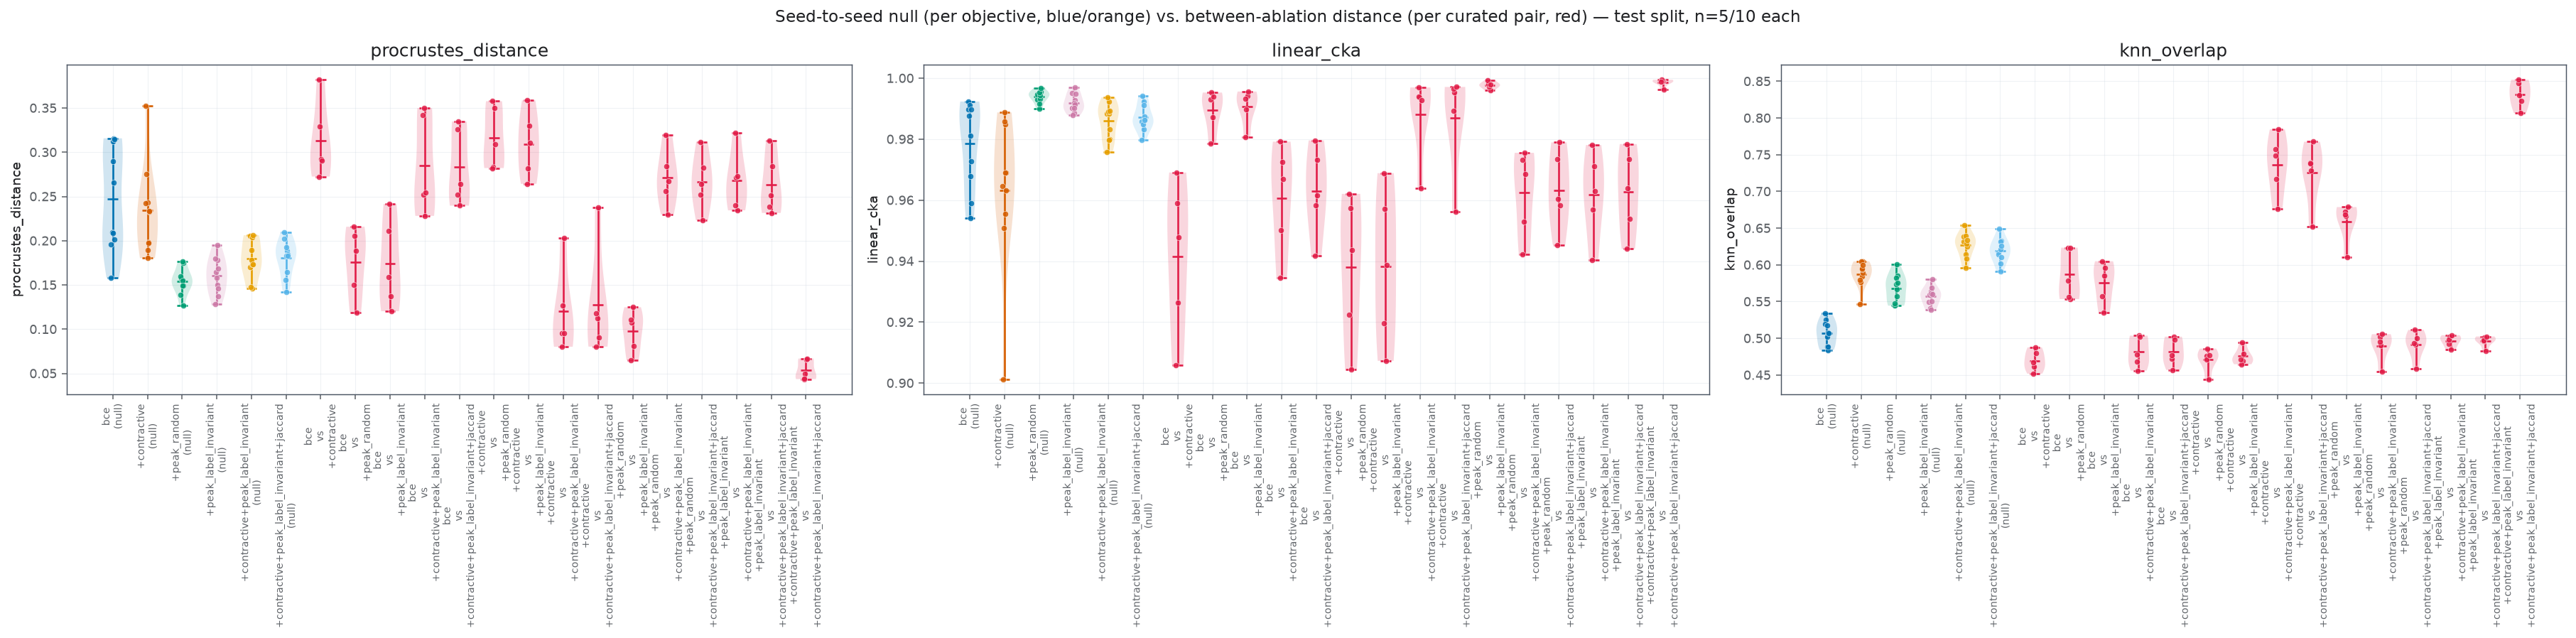

In [ ]:
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

metric_names = ["procrustes_distance", "linear_cka", "knn_overlap"]
figure, axes = plt.subplots(1, len(metric_names), figsize=(26.0, 6.5), dpi=theme.figure_dpi)
for axis, metric_name in zip(axes, metric_names):
    positions, labels = [], []
    for index, objective in enumerate(GRID_ID_BY_OBJECTIVE):
        values = null_frame.loc[null_frame["objective"] == MODEL_LABELS[objective], metric_name].to_numpy()
        plot_violin_with_points(values, position=index, ax=axis, width=0.6, color=theme.color_for_model(MODEL_LABELS[objective], index))
        positions.append(index)
        labels.append(f"{MODEL_LABELS[objective]}\n(null)")
    offset = len(GRID_ID_BY_OBJECTIVE)
    for pair_index, (left_key, right_key) in enumerate(PAIRS):
        pair_label = f"{MODEL_LABELS[left_key]} vs {MODEL_LABELS[right_key]}"
        values = signal_frame.loc[signal_frame["pair"] == pair_label, metric_name].to_numpy()
        x = offset + pair_index
        plot_violin_with_points(values, position=x, ax=axis, width=0.6, color=theme.residual_color)
        positions.append(x)
        labels.append(pair_label.replace(" vs ", "\nvs\n"))
    axis.set_xticks(positions)
    axis.set_xticklabels(labels, fontsize=7, rotation=90)
    axis.set(ylabel=metric_name, title=metric_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Seed-to-seed null (per objective, blue/orange) vs. between-ablation distance (per curated pair, red) — test split, n=5/10 each", fontsize=12)
figure.tight_layout()

## Structure vs. molecule labels (RSA-Spearman)

### Methodology
#### Theoretical
- Whether latent angular distance correlates with molecule-label dissimilarity,
  across all six objectives — extends `part_3`'s AE-only-vs-BCE RSA check to check
  whether the two-cluster geometric split (driven by `+contractive`) also shows up
  in label-relevant structure, not just unlabelled shape statistics.

#### Implementation
- `geometry.rsa_spearman(u, labels, rng, pair_count)` per `(split, objective)`,
  `rep_00` only.

### Notes
- Cluster A (no `+contractive`) sits at Spearman $r$ 0.668-0.718 on test; plain
  `+contractive` is the clear outlier at 0.628, but `grid_0004`/`grid_0005` sit at
  0.667-0.669 — much closer to Cluster A than to `+contractive` alone. This is a
  partial exception to the otherwise clean two-cluster split (see closing notes):
  if it survives a multi-repetition null check, it would mean
  `+peak_label_invariant` partially restores the molecule-label structure that
  `+contractive` alone degrades, even though the *global* geometry stays firmly in
  Cluster B. Flagged as a lead, not a conclusion — single repetition only.


In [16]:
def fetch_targets(partitions, split_name: str, spectrum_ids: list[int]) -> np.ndarray:
    dataset = getattr(partitions, split_name)
    index_by_id = {sid: index for index, sid in enumerate(partitions.manifest.assignments[split_name])}
    ordered_indices = [index_by_id[sid] for sid in spectrum_ids]
    return np.stack([dataset[index][2]["molecule"].numpy() for index in ordered_indices])


rsa_rows = []
rsa_rng = np.random.default_rng(RANDOM_SEED + 2)
for split_name, ids in ids_by_split.items():
    labels = fetch_targets(reference_partitions, split_name, ids)
    for key in MODEL_NAMES:
        u = u_by_split_model[(split_name, key)]
        pairs = min(PAIR_COUNT, u.shape[0] * (u.shape[0] - 1))
        result = geometry.rsa_spearman(u, labels, rsa_rng, pair_count=pairs)
        rsa_rows.append({"split": split_name, "model": MODEL_LABELS[key], **result})

pd.DataFrame(rsa_rows)


,split,model,spearman_r,p_value,pairs
0,train,bce,0.540288,0.0,19998
1,train,+contractive,0.501926,0.0,19994
2,train,+peak_random,0.533682,0.0,19996
3,train,+peak_label_invariant,0.559125,0.0,19996
4,train,+contractive+peak_label_invariant,0.505194,0.0,19995
5,train,+contractive+peak_label_invariant+jaccard,0.507678,0.0,19992
6,test,bce,0.717796,0.0,19995
7,test,+contractive,0.628132,0.0,19996
8,test,+peak_random,0.667840,0.0,19995
9,test,+peak_label_invariant,0.679875,0.0,19996


## Encoder sensitivity — angular curve (test pixels, random-direction perturbation)

### Methodology
#### Theoretical
- How much the latent code moves, in angle, for a small relative perturbation of the
  input spectrum, across all six objectives — `+contractive` explicitly penalizes
  this sensitivity during training, so this is a direct behavioral check of whether
  that penalty visibly changes encoder sensitivity beyond the static-geometry
  collapse already found above.

#### Implementation
- $\varepsilon \mapsto \mathbb{E}\,\angle(u(x), u(x+\varepsilon\lVert x\rVert\delta))$,
  $\delta$ a random unit direction (`geometria_latentu.md` §6.3), swept over
  `EPSILONS`, computed on the test pixels only (genuinely unseen by every model).

### Notes


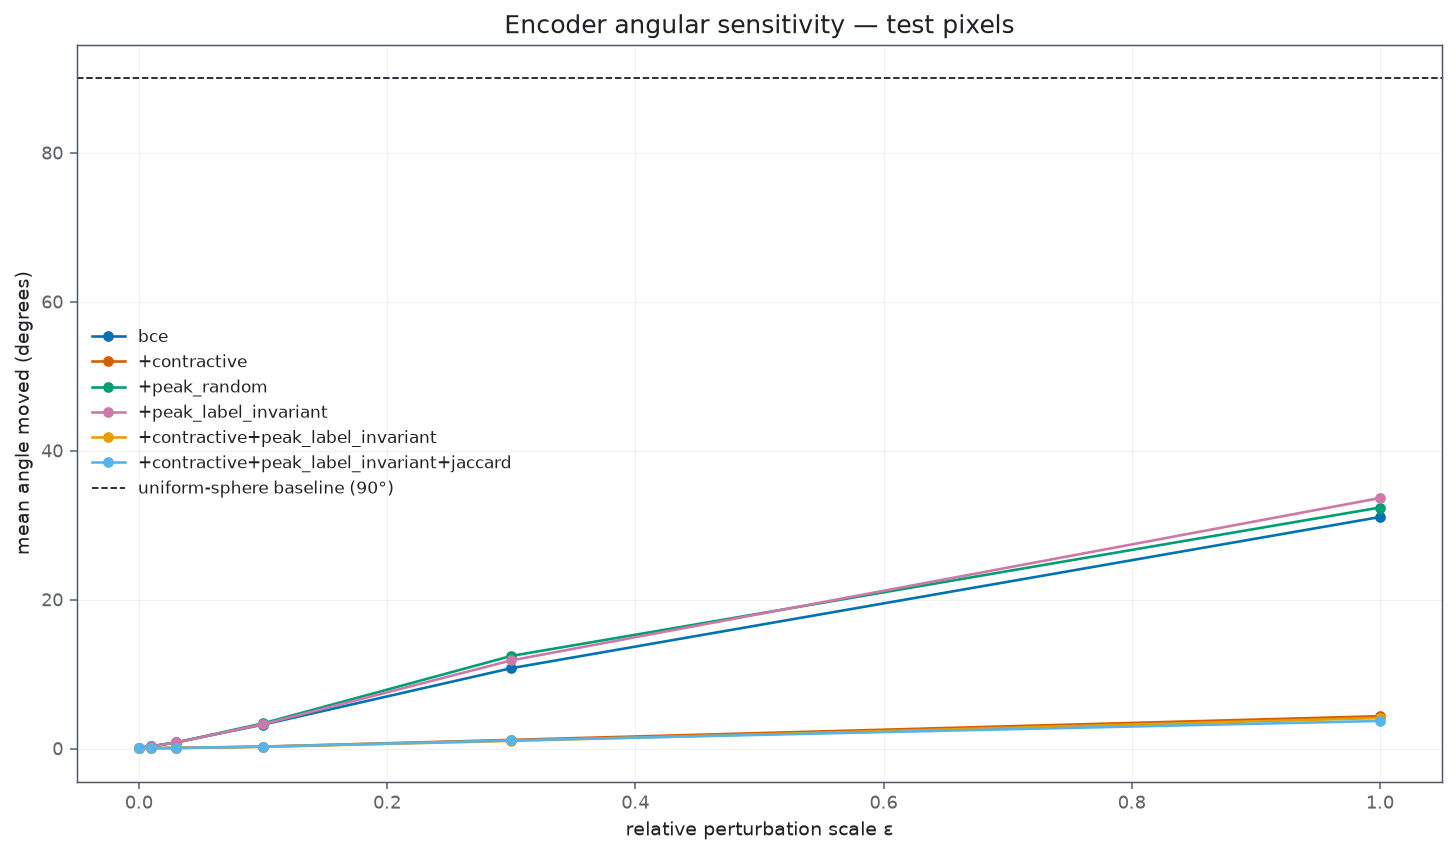

In [17]:
EPSILONS = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0]
sensitivity_rng = np.random.default_rng(RANDOM_SEED + 3)

test_index = {sid: i for i, sid in enumerate(reference_partitions.manifest.assignments["test"])}
test_spectra = torch.stack([reference_partitions.test[test_index[sid]][1] for sid in test_ids]).float().numpy()


def make_encode_fn(model, device, gamma, beta):
    def encode_fn(batch: np.ndarray) -> np.ndarray:
        with torch.no_grad():
            tensor_batch = torch.as_tensor(batch, dtype=torch.float32).to(device)
            z = model(tensor_batch)["latent_space"].cpu().numpy()
        return geometry.canonicalize(z, gamma, beta)

    return encode_fn


sensitivity_curves = {
    key: geometry.angular_sensitivity_curve(
        make_encode_fn(models[key], devices[key], gammas[key], betas[key]), test_spectra, EPSILONS, sensitivity_rng
    )
    for key in MODEL_NAMES
}

figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
for index, key in enumerate(MODEL_NAMES):
    label = MODEL_LABELS[key]
    curve = sensitivity_curves[key]
    ax.plot(curve["epsilon"], curve["mean_angle_degrees"], marker="o", color=theme.color_for_model(label, index), label=label)
ax.axhline(90.0, color=theme.baseline_color, linestyle=theme.baseline_line_style, linewidth=theme.reference_line_width, label="uniform-sphere baseline (90°)")
ax.set(xlabel="relative perturbation scale ε", ylabel="mean angle moved (degrees)", title="Encoder angular sensitivity — test pixels")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(frameon=theme.legend_frame)
figure.tight_layout()


## Does InfoNCE's effect show up more strongly on g(z) than on z?

### Methodology
#### Theoretical
- The loss InfoNCE actually optimizes is computed on `projection` = $g(z)$, not on
  `z` directly — the projector (`Linear(L,L) -> LayerNorm -> ReLU -> Linear(L,64)`)
  sits between them, and `InfoNCELoss` itself L2-normalizes `projection` before
  computing any similarity
  (`training.criterions.autoencoder.contrastive.infoNCE_loss`, both the plain and
  Jaccard-weighted variants). So a weak or absent effect on `z`'s geometry (as found
  above, for `+peak_random`/`+peak_label_invariant` against `bce`) is exactly what
  the SimCLR-style architecture predicts, not evidence the loss failed — gradients
  from InfoNCE only reach `z` after passing back through the projector's own
  nonlinearity. This section checks the loss's own space directly, to see whether
  it shows the between-objective differences `z` did not.

#### Implementation
- `projection`'s raw output has no fixed norm (unlike `z`, which `LayerNorm` fixes
  to $\sqrt D$) — `geometry.normalize_to_constant_norm` reproduces InfoNCE's own
  `F.normalize` step so the rest of this module's toolkit (built on
  `pairwise_cosine`'s fixed-norm assumption) is reusable unmodified. Scope: the four
  objectives that actually train the projector (`+peak_random`,
  `+peak_label_invariant`, `grid_0004`, `grid_0005` — `bce`/`+contractive` never
  include an `InfoNCELoss` term, so their projector is never trained and stays at
  its random initialization, as `part_4`'s identical `projector_first_layer_norm`
  finding already showed). Same seed-noise null check as `z`, from the start.

### Notes
- `g(z)` does *not* show a cleaner separation between InfoNCE variants than `z`
  did — if anything, the opposite. Restricted to the four projector-trained
  objectives, every between-objective signal/null ratio sits right at the noise
  boundary: `+peak_random` vs. `+peak_label_invariant` 0.77; vs.
  `grid_0004`/`grid_0005` 1.00-1.02; `+peak_label_invariant` vs.
  `grid_0004`/`grid_0005` 1.01 both — none comfortably above 1 the way the
  `z`-space cross-cluster pairs were (1.15-1.51). `grid_0004` vs. `grid_0005` stays
  clearly below the null (0.50), matching every other notebook's finding that
  Jaccard weighting changes nothing detectable.
- Important caveat: this only compares InfoNCE-trained variants against each
  other, not against an InfoNCE-absent baseline (`bce`/`+contractive` never train
  the projector, so their `g(z)` is untrained noise and not a meaningful comparison
  point) — so this result specifically says "which peak-selection method" is not
  more visible on `g(z)`, not that InfoNCE has no effect on `g(z)` at all relative
  to no training.


In [18]:
INFO_NCE_OBJECTIVES = {"peak_random": "grid_0002", "peak_label_invariant": "grid_0003", "grid4": "grid_0004", "grid5": "grid_0005"}
PROJECTION_PAIRS = list(itertools.combinations(INFO_NCE_OBJECTIVES, 2))


def encode_projection(model, device, split_name: str, spectrum_ids: list[int]) -> np.ndarray:
    dataset = getattr(reference_partitions, split_name)
    index_by_id = {sid: index for index, sid in enumerate(reference_partitions.manifest.assignments[split_name])}
    ordered_indices = [index_by_id[sid] for sid in spectrum_ids]
    spectra = torch.stack([dataset[index][1] for index in ordered_indices]).float()
    projections = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            batch = spectra[start : start + BATCH_SIZE].to(device)
            projections.append(model(batch)["projection"].cpu().numpy())
    return np.concatenate(projections, axis=0)


p_by_objective_repetition = {}
for objective, grid_id in INFO_NCE_OBJECTIVES.items():
    for repetition in REPETITIONS:
        model_name = f"{CAMPAIGN_ID}__{grid_id}__rep_0{repetition}"
        model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        device = next(model.parameters()).device
        raw_projection = encode_projection(model, device, "test", test_ids)
        p_by_objective_repetition[(objective, repetition)] = geometry.normalize_to_constant_norm(raw_projection)
    print(f"{objective}: encoded projection, 5 repetitions on test")


2026-08-28 14:52:40,759 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.
2026-08-28 14:52:40,760 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.
2026-08-28 14:52:40,760 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder
2026-08-28 14:52:40,762 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.
2026-08-28 14:52:40,764 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.
2026-08-28 14:52:40,767 | INFO     | msi_autoencoder_wrapper.models.architectu

In [19]:
projection_null_rows = []
for objective in INFO_NCE_OBJECTIVES:
    for rep_a, rep_b in combinations(REPETITIONS, 2):
        p_a = p_by_objective_repetition[(objective, rep_a)]
        p_b = p_by_objective_repetition[(objective, rep_b)]
        knn_k = min(KNN_K, p_a.shape[0] - 1)
        projection_null_rows.append({
            "objective": MODEL_LABELS[objective],
            "rep_pair": f"{rep_a}-{rep_b}",
            "procrustes_distance": geometry.procrustes_distance(p_a, p_b),
            "linear_cka": geometry.linear_cka(p_a, p_b),
            "knn_overlap": geometry.knn_overlap(p_a, p_b, k=knn_k),
        })

projection_null_frame = pd.DataFrame(projection_null_rows)
projection_null_summary = projection_null_frame.groupby("objective")[["procrustes_distance", "linear_cka", "knn_overlap"]].agg(["mean", "std"])
projection_null_summary


procrustes_distance            \
                                                         mean       std   
objective                                                                 
+contractive+peak_label_invariant                    0.525803  0.039262   
+contractive+peak_label_invariant+jaccard            0.524122  0.047237   
+peak_label_invariant                                0.509343  0.041217   
+peak_random                                         0.570391  0.043212   

                                          linear_cka           knn_overlap  \
                                                mean       std        mean   
objective                                                                    
+contractive+peak_label_invariant           0.830580  0.040339    0.372481   
+contractive+peak_label_invariant+jaccard   0.814633  0.048950    0.399478   
+peak_label_invariant                       0.858537  0.042010    0.315503   
+peak_random                                0.770481  0.051383    0.316602   

                                                     
                                                std  
objective                                            
+contractive+peak_label_invariant          0.022641  
+contractive+peak_label_invariant+jaccard  0.011132  
+peak_label_invariant                      0.013332  
+peak_random                               0.016541

In [20]:
projection_signal_rows = []
for left_key, right_key in PROJECTION_PAIRS:
    pair_label = f"{MODEL_LABELS[left_key]} vs {MODEL_LABELS[right_key]}"
    for repetition in REPETITIONS:
        p_left = p_by_objective_repetition[(left_key, repetition)]
        p_right = p_by_objective_repetition[(right_key, repetition)]
        knn_k = min(KNN_K, p_left.shape[0] - 1)
        projection_signal_rows.append({
            "pair": pair_label,
            "repetition": repetition,
            "procrustes_distance": geometry.procrustes_distance(p_left, p_right),
        })

projection_signal_frame = pd.DataFrame(projection_signal_rows)

projection_comparison_rows = []
for left_key, right_key in PROJECTION_PAIRS:
    pair_label = f"{MODEL_LABELS[left_key]} vs {MODEL_LABELS[right_key]}"
    signal_values = projection_signal_frame.loc[projection_signal_frame["pair"] == pair_label, "procrustes_distance"]
    null_left = projection_null_frame.loc[projection_null_frame["objective"] == MODEL_LABELS[left_key], "procrustes_distance"]
    null_right = projection_null_frame.loc[projection_null_frame["objective"] == MODEL_LABELS[right_key], "procrustes_distance"]
    larger_null_mean = max(null_left.mean(), null_right.mean())
    projection_comparison_rows.append({
        "pair": pair_label,
        "between_ablation_mean": signal_values.mean(),
        "larger_null_mean": larger_null_mean,
        "signal_over_larger_null": signal_values.mean() / larger_null_mean,
    })

projection_comparison_frame = pd.DataFrame(projection_comparison_rows)
projection_comparison_frame


,pair,between_ablation_mean,larger_null_mean,signal_over_larger_null
0,+peak_random vs +peak_label_invariant,0.440499,0.570391,0.772275
1,+peak_random vs +contractive+peak_label_invariant,0.583313,0.570391,1.022654
2,+peak_random vs +contractive+peak_label_invari...,0.571625,0.570391,1.002164
3,+peak_label_invariant vs +contractive+peak_lab...,0.532996,0.525803,1.013680
4,+peak_label_invariant vs +contractive+peak_lab...,0.527262,0.524122,1.005991
5,+contractive+peak_label_invariant vs +contract...,0.263352,0.525803,0.500857


## Projector ReLU zero-fraction

### Methodology
#### Theoretical
- `geometria_latentu.md`'s note under Część IV: the projector's intermediate
  `LayerNorm(L)` output has zero row-sum by construction (same identity as the
  bottleneck), so the `ReLU` immediately after it necessarily zeroes some
  coordinates for every sample — a zero-sum vector cannot be all-nonnegative unless
  it is exactly zero. This checks how large that fraction actually is, and whether
  it differs by objective.

#### Implementation
- Fraction of post-`LayerNorm`, pre-final-`Linear` projector activations that are
  exactly zero after `ReLU`, computed across all six objectives (`rep_00` only),
  including `bce`/`+contractive` (whose projector is untrained — a baseline for what
  this fraction looks like at random initialization).

### Notes
- 34-51% of post-`LayerNorm` coordinates are zeroed by the following `ReLU`,
  roughly in line with the zero-sum-vector prediction (a zero-sum vector cannot be
  all-nonnegative, so *some* substantial fraction must clip — not a pipeline
  concern at these magnitudes, well short of collapsing the layer entirely).
- Mild pattern worth a closer look, not yet verified as a real effect: the two
  objectives that combine `+contractive` with `InfoNCE` (`grid_0004` 34.2%,
  `grid_0005` 35.0%) sit lower than the two without it (`+peak_random` 43.2%,
  `+peak_label_invariant` 46.9%) — plausibly connected to `+contractive`'s latent
  collapse (a narrower `z` cloud could push more samples' pre-`ReLU` projector
  activations toward the same sign pattern), but this is a hypothesis, not a
  demonstrated mechanism, and single-repetition only.


In [21]:
def relu_zero_fraction(model, device, split_name: str, spectrum_ids: list[int]) -> np.ndarray:
    dataset = getattr(reference_partitions, split_name)
    index_by_id = {sid: index for index, sid in enumerate(reference_partitions.manifest.assignments[split_name])}
    ordered_indices = [index_by_id[sid] for sid in spectrum_ids]
    spectra = torch.stack([dataset[index][1] for index in ordered_indices]).float()
    fractions = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            batch = spectra[start : start + BATCH_SIZE].to(device)
            z = model(batch)["latent_space"]
            pre_relu = model.projector.projection_network[:2](z)  # Linear -> LayerNorm
            post_relu = model.projector.projection_network[2](pre_relu)  # ReLU
            fractions.append((post_relu == 0).float().mean(dim=1).cpu().numpy())
    return np.concatenate(fractions)


relu_zero_rows = []
for objective, grid_id in GRID_ID_BY_OBJECTIVE.items():
    model_name = f"{CAMPAIGN_ID}__{grid_id}__rep_00"
    model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
    model.eval()
    device = next(model.parameters()).device
    fractions = relu_zero_fraction(model, device, "test", test_ids)
    relu_zero_rows.append({
        "objective": MODEL_LABELS[objective],
        "trains_projector": objective in INFO_NCE_OBJECTIVES,
        "mean_zero_fraction": float(fractions.mean()),
        "std_zero_fraction": float(fractions.std()),
    })

pd.DataFrame(relu_zero_rows)


2026-08-28 14:54:08,022 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.
2026-08-28 14:54:08,023 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.
2026-08-28 14:54:08,023 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder
2026-08-28 14:54:08,024 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.
2026-08-28 14:54:08,026 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.
2026-08-28 14:54:08,028 | INFO     | msi_autoencoder_wrapper.models.architectu

,objective,trains_projector,mean_zero_fraction,std_zero_fraction
0,bce,False,0.513025,0.086293
1,+contractive,False,0.416953,0.037588
2,+peak_random,True,0.431718,0.108102
3,+peak_label_invariant,True,0.469302,0.134168
4,+contractive+peak_label_invariant,True,0.342083,0.069273
5,+contractive+peak_label_invariant+jaccard,True,0.350336,0.058562


## Notes for the next pass

**Headline: the latent geometry splits into exactly two clusters, defined purely
by the presence or absence of `+contractive` — every within-cluster pair fails the
seed-noise null check, every cross-cluster pair clears it.**

### The two-cluster structure (test split, Procrustes distance, all 15 pairs)

**Cluster A** = `{bce, +peak_random, +peak_label_invariant}` (no `+contractive`).
**Cluster B** = `{+contractive, grid_0004, grid_0005}` (all include `+contractive`).

| within-cluster pair | signal/null |
|---|---|
| `bce` vs. `+peak_random` | 0.71 |
| `bce` vs. `+peak_label_invariant` | 0.70 |
| `+peak_random` vs. `+peak_label_invariant` | 0.61 |
| `+contractive` vs. `grid_0004` | 0.51 |
| `+contractive` vs. `grid_0005` | 0.54 |
| `grid_0004` vs. `grid_0005` | 0.30 |

| cross-cluster pair | signal/null |
|---|---|
| `bce` vs. `+contractive` | 1.27 |
| `bce` vs. `grid_0004` | 1.15 |
| `bce` vs. `grid_0005` | 1.15 |
| `+contractive` vs. `+peak_random` | 1.35 |
| `+contractive` vs. `+peak_label_invariant` | 1.32 |
| `+peak_random` vs. `grid_0004` | 1.51 |
| `+peak_random` vs. `grid_0005` | 1.48 |
| `+peak_label_invariant` vs. `grid_0004` | 1.49 |
| `+peak_label_invariant` vs. `grid_0005` | 1.46 |

All 6 within-cluster pairs sit below 1 (0.30-0.71); all 9 cross-cluster pairs sit
above 1 (1.15-1.51) — no exceptions, no borderline cases. Whether `+contractive` is
present is the entire story geometrically: which contrastive variant is added
(`+peak_random` vs. `+peak_label_invariant`) and whether `+negw_multilabel_jaccard`
is layered on (`grid_0004` vs. `grid_0005`) are both geometrically invisible by
this metric battery, at 5 repetitions.

### Confirmed by every other metric in this notebook

`cloud_asymmetry` (test): Cluster A 0.35-0.50, Cluster B **0.96-0.97** — same split,
and `grid_0004`/`grid_0005` collapse *at least as much* as plain `+contractive`
(0.966/0.970 vs. 0.957), not less. `trace(Cov(u))` (test): Cluster A 5.0-6.5,
Cluster B **0.30-0.43** — same split, same direction (`grid_0004`/`grid_0005`
slightly *more* collapsed than plain `+contractive`). `linear_cka`/`knn_overlap` in
the pairwise table above show the identical clustering directly (Cluster-B-internal
CKA 0.986-0.999; cross-cluster CKA 0.90-0.98). TwoNN intrinsic dimension shows the
same split far more mildly (Cluster A ~5.7-5.75 vs. Cluster B ~5.2-5.3) — expected,
since TwoNN is largely insensitive to the isotropic-scale collapse `+contractive`
produces (`part_4`'s original finding, confirmed again here).

### One partial exception, not null-checked

RSA-vs-labels (test, `rep_00` only): Cluster A sits at 0.668-0.718; plain
`+contractive` is the clear outlier at 0.628, but `grid_0004`/`grid_0005` sit at
0.667-0.669 — much closer to Cluster A than to `+contractive`. If this survives a
5-repetition null check, it would mean `+peak_label_invariant` partially restores
the molecule-label structure that `+contractive` alone degrades, even though the
*global* geometry (Procrustes/CKA/asymmetry) stays firmly in Cluster B. Flagged as
a lead, not a conclusion — single repetition only.

### Combined with `part_5`/`part_6`

The two-cluster geometric split does **not** line up cleanly with the downstream
pattern. `part_5` found `+peak_label_invariant` → `grid_0004` (adding
`+contractive`, i.e. crossing from Cluster A to Cluster B) is a real reconstruction
*regression*; `part_6` found the same crossing has no detectable classification
effect. So: crossing the cluster boundary is a large, unambiguous geometric event,
but its downstream consequence is metric-specific (costs reconstruction, leaves
classification alone) rather than uniformly bad or uniformly harmless. `grid_0004`
vs. `grid_0005` (`+negw_multilabel_jaccard`) is geometrically invisible here
(0.30, within Cluster B) and was also undetectable in both `part_5` (0.11) and
`part_6` (0.26) — the most consistent null result across all three notebooks.

**Balanced_bce-family latent-geometry conclusion**: `+contractive`'s presence, not
which contrastive term or negative-weighting scheme accompanies it, is what
determines the representation's geometry. Combined with `part_5`/`part_6`, the
case for `grid_0003` (`+peak_label_invariant` alone) over `grid_0004`/`grid_0005`
stands: adding `+contractive` produces a large geometric shift and a real
reconstruction cost, for no measured classification benefit.

Not yet done, worth a follow-up: alignment/uniformity and the
contrastive-selectivity angular curve (`../report/geometria_latentu.md`'s
contrastive-specific checklist) — both need `InfoNCELoss`'s own peak-permutation
augmentation reused directly, deferred per the intro above. A 5-repetition RSA
check would resolve whether the partial exception noted above is real.

### Addendum: g(z) and the projector's ReLU zero-fraction

**g(z) does *not* show a cleaner separation between InfoNCE variants than `z`
did — if anything, the opposite.** Restricted to the four objectives that
actually train the projector (`+peak_random`, `+peak_label_invariant`,
`grid_0004`, `grid_0005`), every between-objective signal/null ratio on
`normalize_to_constant_norm(projection)` sits right at the noise boundary:
`+peak_random` vs. `+peak_label_invariant` 0.77; vs. `grid_0004`/`grid_0005`
1.00-1.02; `+peak_label_invariant` vs. `grid_0004`/`grid_0005` 1.01 both — none
comfortably above 1 the way the `z`-space cross-cluster pairs were (1.15-1.51).
`grid_0004` vs. `grid_0005` stays clearly below the null (0.50), matching every
other notebook's finding that Jaccard weighting changes nothing detectable. This
was originally expected to show InfoNCE's effect *more* clearly, since that is
the literal space the loss optimizes — it does not. Important caveat: this only
compares InfoNCE-trained variants against each other, not against an
InfoNCE-absent baseline (`bce`/`+contractive` never train the projector, so their
`g(z)` is untrained noise and not a meaningful comparison point) — so this result
specifically says "which peak-selection method" is not more visible on `g(z)`,
not that InfoNCE has no effect on `g(z)` at all relative to no training.
- **Projector ReLU zero-fraction** (Część IV's "Uwaga", `rep_00` only): 34-51%
  of post-`LayerNorm` coordinates are zeroed by the following `ReLU`, roughly in
  line with the zero-sum-vector prediction (a zero-sum vector cannot be
  all-nonnegative, so *some* substantial fraction must clip — not a pipeline
  concern at these magnitudes, well short of collapsing the layer entirely).
  Mild pattern worth a closer look, not yet verified as a real effect: the two
  objectives that combine `+contractive` with `InfoNCE` (`grid_0004` 34.2%,
  `grid_0005` 35.0%) sit lower than the two without it (`+peak_random` 43.2%,
  `+peak_label_invariant` 46.9%) — plausibly connected to `+contractive`'s latent
  collapse (a narrower `z` cloud could push more samples' pre-`ReLU` projector
  activations toward the same sign pattern), but this is a hypothesis, not a
  demonstrated mechanism, and single-repetition only.
